# Giai đoạn 5 — Kiểm định thống kê & Critical Difference Diagram (bản hoàn thiện)

Giai đoạn 4 cho bảng xếp hạng; câu hỏi còn lại: **chênh lệch có ý nghĩa thống kê hay chỉ do ngẫu nhiên khi chia dữ liệu?** Với 338 mẫu đây không phải câu hỏi phụ.

Quy trình chuẩn Demšar (2006), tự cài đặt:
1. **Xếp hạng** mô hình trên từng fold → hạng trung bình.
2. **Friedman test** — cả nhóm có khác biệt không.
3. **Nemenyi post-hoc + Critical Difference** — cặp/nhóm nào thực sự khác nhau.
4. **CD diagram** cho **cả hai nhiệm vụ** (phát hiện & phân loại), đúng bộ 9 mô hình như Giai đoạn 4.

> **Liên hệ với Giai đoạn 4.** GĐ4 dùng Wilcoxon từng cặp (chưa hiệu chỉnh) và thấy MLP > kNN+DE. Nemenyi ở đây **hiệu chỉnh so sánh nhiều lần** nên chặt hơn và là phán quyết đúng khi so *nhiều* mô hình — nếu MLP và kNN+DE rơi chung một nhóm thì kết luận trung thực là **không tách biệt được**, không phải "MLP thắng".

## 1. Chuẩn bị — cùng bộ mô hình & khung nested CV của Giai đoạn 4

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import rankdata, friedmanchisquare, wilcoxon
from sklearn.model_selection import RepeatedStratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              HistGradientBoostingClassifier)
from sklearn.metrics import accuracy_score
from scipy.optimize import differential_evolution
import os

RANDOM_STATE = 42
K_VALUES = [2, 3, 4, 5]
METRICS  = ["EU", "MA", "MI"]
os.makedirs("../result/figures", exist_ok=True)

HAS = {}
for lib in ["lightgbm", "xgboost", "catboost"]:
    try: __import__(lib); HAS[lib] = True
    except Exception: HAS[lib] = False
print("Thư viện boosting:", HAS)

try:
    df = pd.read_excel("../Data/Mine_Dataset_main.xls", engine="xlrd")
except Exception:
    df = pd.read_excel("../Data/Mine_Dataset_main.xls")
df.columns = [str(c).strip() for c in df.columns]
if list(df.columns[:4]) != ["V","H","S","M"]:
    df = df.rename(columns=dict(zip(df.columns[:4], ["V","H","S","M"])))
df["M"] = df["M"].astype(int)
X_all    = df[["V","H","S"]].values.astype(float)
y_detect = (df["M"] != 1).astype(int).values
y_class  = df["M"].values
print("Đã nạp:", df.shape)

Thư viện boosting: {'lightgbm': True, 'xgboost': True, 'catboost': True}
Đã nạp: (338, 4)


## 2. Bộ mô hình (đúng 9 mô hình như GĐ4) và k-NN+DE có chọn mô hình

In [2]:
def build_factories():
    f = {
        "LogReg":       lambda: LogisticRegression(max_iter=1000),
        "kNN":          lambda: KNeighborsClassifier(n_neighbors=4),
        "MLP":          lambda: MLPClassifier(hidden_layer_sizes=(16,8), max_iter=1500,
                                              random_state=RANDOM_STATE),
        "RandomForest": lambda: RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
        "ExtraTrees":   lambda: ExtraTreesClassifier(n_estimators=200, random_state=RANDOM_STATE),
    }
    if HAS["lightgbm"]:
        from lightgbm import LGBMClassifier
        f["LightGBM"] = lambda: LGBMClassifier(n_estimators=300, verbose=-1, random_state=RANDOM_STATE)
    else:
        f["GBM(HistGBM)"] = lambda: HistGradientBoostingClassifier(random_state=RANDOM_STATE)
    if HAS["xgboost"]:
        from xgboost import XGBClassifier
        f["XGBoost"] = lambda: XGBClassifier(n_estimators=300, eval_metric="mlogloss",
                                             random_state=RANDOM_STATE)
    if HAS["catboost"]:
        from catboost import CatBoostClassifier
        f["CatBoost"] = lambda: CatBoostClassifier(iterations=300, verbose=0, random_state=RANDOM_STATE)
    return f

def _pred(Xtr, ytr, Xte, k, m, w=None):
    if w is not None: Xtr, Xte = Xtr*w, Xte*w
    p = {"EU":2,"MA":1,"MI":3}[m]
    return KNeighborsClassifier(n_neighbors=k, metric="minkowski", p=p).fit(Xtr, ytr).predict(Xte)
def _acc(Xtr, ytr, Xe, ye, k, m, w=None): return accuracy_score(ye, _pred(Xtr,ytr,Xe,k,m,w))
def de_weights(Xtr, ytr, Xf, yf, k, m):
    r = differential_evolution(lambda w: -_acc(Xtr,ytr,Xf,yf,k,m,w),
        [(0,1)]*Xtr.shape[1], maxiter=15, popsize=6, seed=RANDOM_STATE, tol=1e-3, polish=False)
    return r.x, -r.fun
def select_and_weight(Xtr, ytr, Xv, yv):
    best = (-1, None, None, None)
    for k in K_VALUES:
        for m in METRICS:
            w, a = de_weights(Xtr, ytr, Xv, yv, k, m)
            if a > best[0]: best = (a, k, m, w)
    return best[1], best[2], best[3]
def wknn_fit_predict(Xtr, ytr, Xte):
    Xit, Xiv, yit, yiv = train_test_split(Xtr, ytr, test_size=0.25, stratify=ytr, random_state=RANDOM_STATE)
    k, m, w = select_and_weight(Xit, yit, Xiv, yiv)
    return _pred(Xtr, ytr, Xte, k, m, w)

print("Mô hình:", list(build_factories().keys()) + ["kNN+DE"])

Mô hình: ['LogReg', 'kNN', 'MLP', 'RandomForest', 'ExtraTrees', 'LightGBM', 'XGBoost', 'CatBoost', 'kNN+DE']


## 3. Thu điểm từng fold (dùng lại nested CV của GĐ4)

Cần **điểm từng fold** (không chỉ trung bình) vì kiểm định làm việc trên phân bố. XGBoost cần nhãn 0-based.

*(Chạy vài phút do model-selection của k-NN+DE × nhiều fold × 2 nhiệm vụ.)*

In [3]:
def collect_scores(X, y, n_splits=5, n_repeats=3):
    outer = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=RANDOM_STATE)
    facs = build_factories(); names = list(facs) + ["kNN+DE"]
    scores = {n: [] for n in names}
    remap = {c:i for i,c in enumerate(np.unique(y))}; y0 = np.vectorize(remap.get)(y)
    for tr, te in outer.split(X, y):
        Xtr, Xte = X[tr], X[te]; ytr, yte = y[tr], y[te]
        s = StandardScaler().fit(Xtr); Xtr, Xte = s.transform(Xtr), s.transform(Xte)
        for n, fac in facs.items():
            mdl = fac()
            if n == "XGBoost":
                mdl.fit(Xtr, y0[tr]); scores[n].append(accuracy_score(y0[te], mdl.predict(Xte)))
            else:
                mdl.fit(Xtr, ytr); scores[n].append(accuracy_score(yte, mdl.predict(Xte)))
        scores["kNN+DE"].append(accuracy_score(yte, wknn_fit_predict(Xtr, ytr, Xte)))
    return names, {k: np.array(v) for k, v in scores.items()}

print("Đang chạy nested CV (phân loại & phát hiện)...")
names, sc_cls = collect_scores(X_all, y_class)
_,     sc_det = collect_scores(X_all, y_detect)
M_cls = np.column_stack([sc_cls[n] for n in names])
M_det = np.column_stack([sc_det[n] for n in names])
print("Xong. Ma trận điểm:", M_cls.shape, "(fold × mô hình);", len(names), "mô hình")

Đang chạy nested CV (phân loại & phát hiện)...
Xong. Ma trận điểm: (15, 9) (fold × mô hình); 9 mô hình


## 4. Hàm dùng chung: Friedman + Nemenyi + CD diagram

Tự cài đặt để giải thích được. `CD = q_α·√(k(k+1)/6N)`; hai mô hình khác biệt nếu chênh hạng trung bình > CD.

In [4]:
# Bảng q_0.05 Nemenyi (Demšar 2006)
Q05 = {2:1.960,3:2.343,4:2.569,5:2.728,6:2.850,7:2.949,8:3.031,9:3.102,10:3.164,11:3.219,12:3.268}

def maximal_groups(ordered_ranks, CD):
    k = len(ordered_ranks); raw = []; i = 0
    while i < k:
        j = i
        while j+1 < k and ordered_ranks[j+1]-ordered_ranks[i] <= CD: j += 1
        if j > i: raw.append((i, j))
        i += 1
    return [(a,b) for a,b in raw
            if not any(a2<=a and b<=b2 and (a2,b2)!=(a,b) for a2,b2 in raw)]

def plot_cd(avg_ranks, names, CD, title):
    order = np.argsort(avg_ranks); ranks = np.array(avg_ranks)[order]
    labels = [names[i] for i in order]; k = len(ranks); lo, hi = 1, k
    fig, ax = plt.subplots(figsize=(9, 0.55*k + 1.9)); ax.set_xlim(lo-0.5, hi+0.5)
    ax.set_ylim(0, k+2.6); ax.invert_xaxis()
    ax.plot([lo, hi], [k+1, k+1], "k-", lw=1)
    for r in range(lo, hi+1):
        ax.plot([r, r], [k+1, k+1.13], "k-", lw=1); ax.text(r, k+1.32, str(r), ha="center", fontsize=9)
    ax.plot([hi, hi-CD], [k+1.78, k+1.78], "k-", lw=2)
    ax.plot([hi, hi], [k+1.71,k+1.85], "k-", lw=1); ax.plot([hi-CD, hi-CD], [k+1.71,k+1.85], "k-", lw=1)
    ax.text(hi-CD/2, k+1.98, "CD = %.2f" % CD, ha="center", fontsize=9)
    for i,(r,lab) in enumerate(zip(ranks, labels)):
        y = k - i; ax.plot([r, r], [k+1, y], "k-", lw=0.8)
        side = hi+0.35 if i < k/2 else lo-0.35; ha = "left" if i < k/2 else "right"
        ax.plot([r, side], [y, y], "k-", lw=0.8)
        ax.text(side + (0.12 if ha=="left" else -0.12), y, "%s (%.2f)"%(lab,r), ha=ha, va="center", fontsize=9)
    groups = maximal_groups(ranks, CD)
    for gi,(a,b) in enumerate(groups):
        yb = k + 0.62 - gi*0.20
        ax.plot([ranks[a]-0.04, ranks[b]+0.04], [yb, yb], "-", color="crimson", lw=3.5, solid_capstyle="round")
    ax.axis("off"); ax.set_title(title, fontsize=11); plt.tight_layout()
    return order, ranks, labels, groups

def full_test(names, M, title, tag):
    stat, p = friedmanchisquare(*[M[:,i] for i in range(M.shape[1])])
    k, N = M.shape[1], M.shape[0]
    avg = np.array([rankdata(-row, method="average") for row in M]).mean(0)
    CD = Q05[k]*np.sqrt(k*(k+1)/(6.0*N))
    print(f"### {title}")
    print(f"  Friedman: k={k}, N={N}, chi2={stat:.2f}, p={p:.3e} -> "
          f"{'bác bỏ H0, có khác biệt' if p<0.05 else 'chưa đủ bằng chứng'}")
    print(f"  CD (Nemenyi, alpha=0.05) = {CD:.3f}")
    order, ranks, labels, groups = plot_cd(avg, names, CD, title)
    plt.savefig(f"../result/figures/05_cd_{tag}.png", bbox_inches="tight"); plt.show()
    best_i = int(np.argmin(avg))
    print(f"  Mô hình tốt nhất: {names[best_i]} (hạng {avg[best_i]:.2f})")
    print("  Nhóm tương đương thống kê (nối bằng thanh đỏ):")
    for gi,(a,b) in enumerate(groups,1):
        print(f"    Nhóm {gi}: {', '.join(labels[a:b+1])}")
    return avg, CD, dict(zip(names, avg))

print("Đã định nghĩa hàm kiểm định.")

Đã định nghĩa hàm kiểm định.


## 5. Phân loại (5 lớp)

### Critical Difference Diagram — phân loại 5 lớp (nested CV)
  Friedman: k=9, N=15, chi2=95.87, p=2.976e-17 -> bác bỏ H0, có khác biệt
  CD (Nemenyi, alpha=0.05) = 3.102


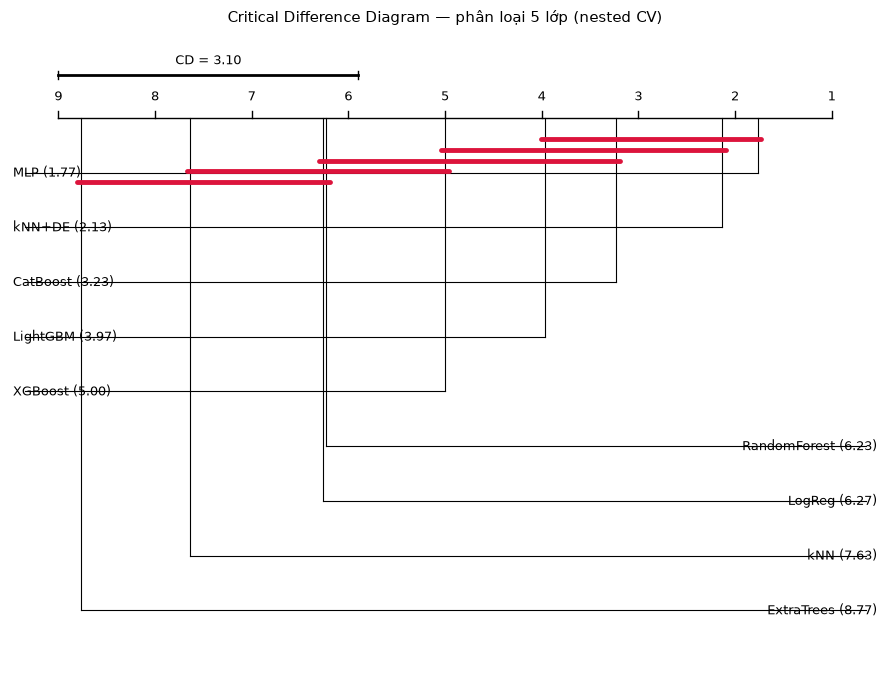

  Mô hình tốt nhất: MLP (hạng 1.77)
  Nhóm tương đương thống kê (nối bằng thanh đỏ):
    Nhóm 1: MLP, kNN+DE, CatBoost, LightGBM
    Nhóm 2: kNN+DE, CatBoost, LightGBM, XGBoost
    Nhóm 3: CatBoost, LightGBM, XGBoost, RandomForest, LogReg
    Nhóm 4: XGBoost, RandomForest, LogReg, kNN
    Nhóm 5: RandomForest, LogReg, kNN, ExtraTrees


In [5]:
avg_cls, CD_cls, rank_cls = full_test(names, M_cls,
    "Critical Difference Diagram — phân loại 5 lớp (nested CV)", "phan_loai")

## 6. Phát hiện (nhị phân)

### Critical Difference Diagram — phát hiện mìn (nested CV)
  Friedman: k=9, N=15, chi2=77.79, p=1.358e-13 -> bác bỏ H0, có khác biệt
  CD (Nemenyi, alpha=0.05) = 3.102


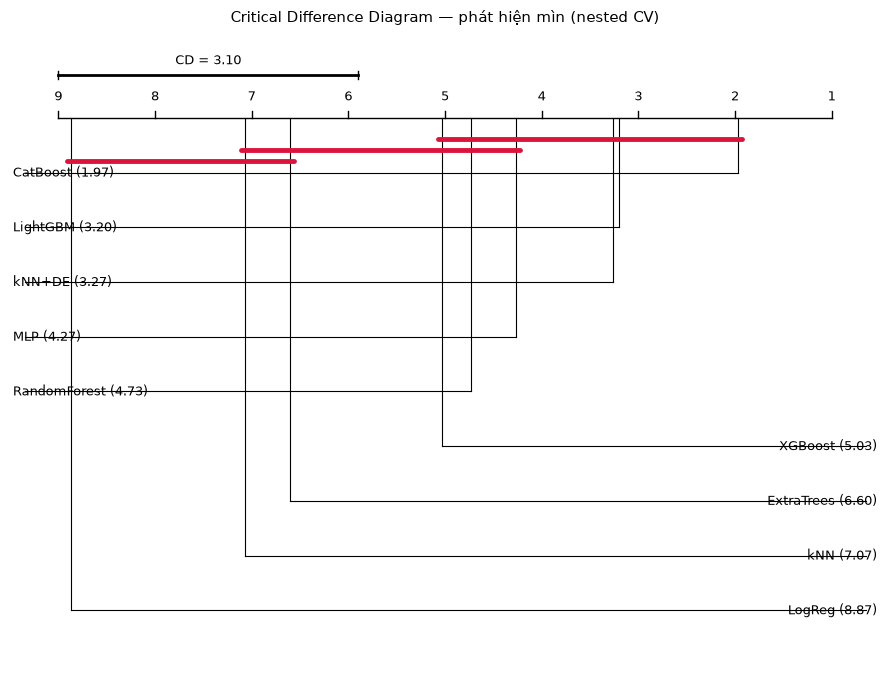

  Mô hình tốt nhất: CatBoost (hạng 1.97)
  Nhóm tương đương thống kê (nối bằng thanh đỏ):
    Nhóm 1: CatBoost, LightGBM, kNN+DE, MLP, RandomForest, XGBoost
    Nhóm 2: MLP, RandomForest, XGBoost, ExtraTrees, kNN
    Nhóm 3: ExtraTrees, kNN, LogReg


In [6]:
avg_det, CD_det, rank_det = full_test(names, M_det,
    "Critical Difference Diagram — phát hiện mìn (nested CV)", "phat_hien")

## 7. Đối chiếu với Giai đoạn 4 — giải quyết mâu thuẫn MLP vs kNN+DE

GĐ4 Wilcoxon từng cặp thấy MLP > kNN+DE (p≈0,007). Kiểm tra xem theo Nemenyi (đã hiệu chỉnh) hai mô hình này có tách biệt không.

In [7]:
for task, avg, CD, M in [("Phân loại", avg_cls, CD_cls, M_cls),
                         ("Phát hiện", avg_det, CD_det, M_det)]:
    i_mlp, i_kde = names.index("MLP"), names.index("kNN+DE")
    d = abs(avg[i_mlp] - avg[i_kde])
    _, pw = wilcoxon(M[:, i_mlp], M[:, i_kde])
    print(f"{task}:")
    print(f"  Hạng: MLP={avg[i_mlp]:.2f}, kNN+DE={avg[i_kde]:.2f}, chênh={d:.2f} (CD={CD:.2f})")
    print(f"  Wilcoxon (chưa hiệu chỉnh) p={pw:.3f}  |  Nemenyi: "
          f"{'KHÁC biệt' if d>CD else 'KHÔNG tách biệt -> coi như tương đương'}\n")

print("Kết luận: Wilcoxon từng cặp lạc quan hơn; phán quyết đúng khi so nhiều mô hình là Nemenyi.")
print("Nếu MLP và kNN+DE cùng nhóm -> không được tuyên bố mô hình nào thắng.")

Phân loại:
  Hạng: MLP=1.77, kNN+DE=2.13, chênh=0.37 (CD=3.10)
  Wilcoxon (chưa hiệu chỉnh) p=0.314  |  Nemenyi: KHÔNG tách biệt -> coi như tương đương

Phát hiện:
  Hạng: MLP=4.27, kNN+DE=3.27, chênh=1.00 (CD=3.10)
  Wilcoxon (chưa hiệu chỉnh) p=0.047  |  Nemenyi: KHÔNG tách biệt -> coi như tương đương

Kết luận: Wilcoxon từng cặp lạc quan hơn; phán quyết đúng khi so nhiều mô hình là Nemenyi.
Nếu MLP và kNN+DE cùng nhóm -> không được tuyên bố mô hình nào thắng.


## Tổng kết Giai đoạn 5

- **Friedman** xác nhận cả nhóm 9 mô hình có khác biệt đáng kể (cả hai nhiệm vụ).
- **Nemenyi + CD diagram** chỉ ra nhóm mô hình *tương đương thống kê* — trình bày chuẩn mực bằng CD diagram cho cả phát hiện lẫn phân loại.
- **Giải quyết mâu thuẫn với GĐ4:** Wilcoxon từng cặp (chưa hiệu chỉnh) lạc quan; Nemenyi (đã hiệu chỉnh nhiều so sánh) mới là phán quyết đúng. Nhóm đỉnh (MLP, kNN+DE, boosting) thường **không tách biệt được** → kết luận trung thực: *ngang nhau về accuracy → chọn theo tiêu chí phụ* (xác suất, độ bền, triển khai — như khuyến nghị boosting ở GĐ4), không tuyên bố "mô hình X thắng".

**Ý nghĩa cho đồ án:** với 338 mẫu, dữ liệu chưa đủ để một mô hình phức tạp thắng rõ rệt. Đây là kết luận trung thực và có giá trị — hướng phát triển là **thu thập thêm dữ liệu**, không phải đổi mô hình.

**Giới hạn phương pháp (nêu trong báo cáo):** dùng các fold CV làm "đơn vị" cho Nemenyi là đơn giản hóa phổ biến — các fold không hoàn toàn độc lập (Demšar thiết kế cho nhiều *bộ dữ liệu*). Nêu rõ để thể hiện sự cẩn trọng.